In [96]:
import pandas as pd

# Example Notebook: Introductory Data Science
This notebook demonstrates core data science concepts such as grouping, aggregation, and data visualization.

## Agenda
- Adjusting and selecting columns  
- Creating simple visualizations  

## Adjusting columns

We will be working with the `states` DataFrame.

In [97]:
states = pd.read_csv('data/states.csv')
states = states.assign(Density=states['Population'] / states['Land Area'])
states = states.set_index('State')
states.head()

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,
Alabama,South,Montgomery,5024279,50645,Republican,99.205825
Alaska,West,Juneau,733391,570641,Republican,1.285206
Arizona,West,Phoenix,7151502,113594,Republican,62.956688
Arkansas,South,Little Rock,3011524,52035,Republican,57.874969
California,West,Sacramento,39538223,155779,Democratic,253.809711


Notice the column names don't make sense after grouping with the `.count()` aggregation method.

In [98]:
states.groupby('Region').count()

,Capital City,Population,Land Area,Party,Density
Region,,,,,
Midwest,12,12,12,12,12
Northeast,9,9,9,9,9
South,16,16,16,16,16
West,13,13,13,13,13


### Adjusting columns with `.assign`, `.drop`, and column selection

1. To create or rename a column, use `.assign()` to add a new column or modify an existing one.
    - New columns are added on the right.

2. Then use `.drop(columns=list_of_column_labels)` to drop any columns you no longer need. 
    - Alternatively, select specific columns with `df[[list_of_column_names]]` to keep only those columns.  
     This approach also lets you control the column order.

### Two ways to select column(s)

1. Selecting a single column using its name returns a Series.  
2. Selecting a list of column names returns a DataFrame, even if the list has just one element.

In [99]:
states['Capital City'].head()

State
Alabama        Montgomery
Alaska             Juneau
Arizona           Phoenix
Arkansas      Little Rock
California     Sacramento
Name: Capital City, dtype: object

In [100]:
states[['Capital City', 'Party']].head()

,Capital City,Party
State,,
Alabama,Montgomery,Republican
Alaska,Juneau,Republican
Arizona,Phoenix,Republican
Arkansas,Little Rock,Republican
California,Sacramento,Democratic


### Activity

Change the DataFrame `states_by_region` so that it only has one column, called `'Count'`, containing the number of states in each region.

In [101]:
states_by_region = states.groupby('Region').count()
states_by_region

,Capital City,Population,Land Area,Party,Density
Region,,,,,
Midwest,12,12,12,12,12
Northeast,9,9,9,9,9
South,16,16,16,16,16
West,13,13,13,13,13


## Why visualize?

- Computers are better than humans at crunching numbers, but humans are better at identifying visual patterns.
- Visualizations allow us to understand lots of data quickly – they make it easier to spot trends and communicate our results.
- There are many types of visualizations, including scatter plots, line plots, bar charts, and histograms.  
  - The right choice depends on the type of data and the question we want to answer.

## Terminology

### Individuals and variables

- <span style="color:#6d9eeb"><b>Individual (row)</b></span>: Person/place/thing for which data is recorded. Also called an **observation**.

- <span style="color:#ff9900"><b>Variable (column)</b></span>: Something that is recorded for each individual. Also called a **feature**.

### Types of variables

There are two main types of variables:

- **Numerical**: It makes sense to do arithmetic with the values.
- **Categorical**: Values fall into categories, that may or may not have some _order_ to them.

Note that here, "variable" does not mean a variable in Python, but rather it means a column in a DataFrame.

### Examples of numerical variables

- Salaries of NBA players 🏀.
    - Individual: An NBA player.
    - Variable: Their salary.
- Company's annual profit 💰.
    - Individual: A company.
    - Variable: Its annual profit.
- Flu shots administered per day 💉.
    - Individual: Date.
    - Variable: Number of flu shots administered on that date.

### Examples of categorical variables

- Movie genres 🎬.
    - Individual: A movie.
    - Variable: Its genre.
- Zip codes 🏠.
    - Individual: US resident.
    - Variable: Zip code.
        - Even though they look like numbers, zip codes are categorical (arithmetic doesn't make sense).
- Level of prior programming experience for students in an introductory data science course 🧑‍🎓.
    - Individual: A student.
    - Variable: Their level of prior programming experience, e.g. none, low, medium, or high. 
        - There is an _order_ to these categories!

### Concept Check ✅

Which of these is *not* a numerical variable?

A. Fuel economy in miles per gallon.  
B. Number of semesters completed.  
C. College affiliation (Arts, Engineering, etc).  
D. Bank account number.  
E. More than one of these are not numerical variables.

### Types of visualizations

The type of visualization we create depends on the kinds of variables we're visualizing.

- **Scatter plot**: Numerical vs. numerical.
- **Line plot**: Sequential numerical (time) vs. numerical.
- **Bar chart**: Categorical vs. numerical.
- **Histogram**: Numerical.
    
We may interchange the words "plot", "chart", and "graph"; they all mean the same thing.

## Scatter plots

### The data: exoplanets discovered by NASA 🪐

An [exoplanet](https://exoplanets.nasa.gov/what-is-an-exoplanet/overview/) is a planet outside our solar system. NASA has discovered over 5,000 exoplanets so far in its [search for signs of life beyond Earth](https://exoplanets.nasa.gov/search-for-life/big-questions/). 👽 

|Column |Contents|
|----------|------------|
`'Distance'`| Distance from Earth, in light years.
`'Magnitude'`|	[Apparent magnitude](https://en.wikipedia.org/wiki/Apparent_magnitude#), which measures brightness in such a way that brighter objects have **lower** values.
`'Type'`|  Categorization of planet based on its composition and size.
`'Year'`|	When the planet was discovered.
`'Detection'`|	The method of detection used to discover the planet.
`'Mass'`|	The ratio of the planet's mass to Earth's mass. 
`'Radius'`|  The ratio of the planet's radius to Earth's radius.

In [102]:
exo = pd.read_csv('data/exoplanets.csv').set_index('Name')
exo.head()

,Distance,Magnitude,Type,Year,Detection,Mass,Radius
Name,,,,,,,
11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,Radial Velocity,6165.902000,11.88
11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,Radial Velocity,4684.814200,11.99
14 Andromedae b,246.0,5.23133,Gas Giant,2008,Radial Velocity,1525.584000,12.65
14 Herculis b,58.0,6.61935,Gas Giant,2002,Radial Velocity,2586.757982,12.32
16 Cygni B b,69.0,6.21500,Gas Giant,1996,Radial Velocity,565.737400,13.20


- What is the relationship between `'Distance'` and `'Magnitude'`?

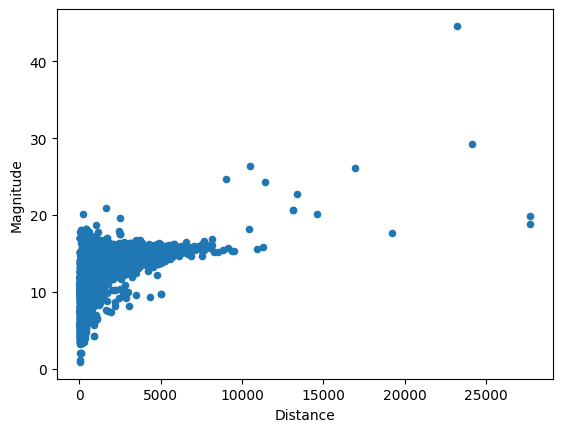

In [103]:
exo.plot(kind='scatter', x='Distance', y='Magnitude');

- Further planets have greater `'Magnitude'` (meaning they are less bright), which makes sense.

- The data appears curved because `'Magnitude'` is measured on a logarithmic scale. A decrease of one unit in `'Magnitude'` corresponds to a 2.5 times increase in brightness.

### Understanding Scatter plots

- Scatter plots visualize the relationship between two numerical variables.
- To create one from a DataFrame `df`, use
```py
df.plot(
    kind='scatter', 
    x=x_column_for_horizontal, 
    y=y_column_for_vertical
)
```
- The resulting scatter plot has one point per row of `df`.
- If you put a semicolon after a call to `.plot`, it will hide the weird text output that displays.

### Zooming in 🔍

The majority of exoplanets are less than 10,000 light years away; if we'd like to zoom in on just these exoplanets, we can query before plotting.

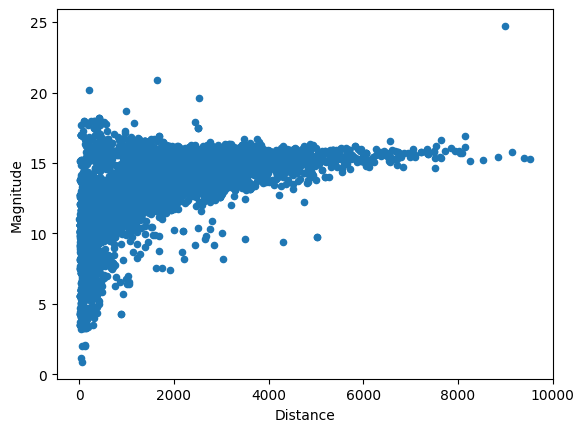

In [104]:
exo[exo['Distance'] < 10000].plot(kind='scatter', x='Distance', y='Magnitude');

## Line plots 📉

- How has the `'Magnitude'` of newly discovered exoplanets changed over time?
- Let's calculate the average `'Magnitude'` of all exoplanets discovered in each `'Year'`.

In [118]:
exo.groupby('Year')['Magnitude'].mean()

Year
1995     5.453090
1996     5.124907
1997     5.408160
1998     7.414268
1999     6.376047
2000     6.775369
2001     7.282210
2002     7.568210
2003     6.825174
2004    10.136479
2005     7.889754
2006     8.720184
2007     9.324000
2008     8.691593
2009     9.070121
2010    10.379602
2011    11.613615
2012    11.935760
2013    12.014302
2014    14.051228
2015    11.668427
2016    14.243943
2017    11.549400
2018    12.042468
2019    11.275383
2020    12.318458
2021    13.008794
2022    10.623236
2023    12.085444
Name: Magnitude, dtype: float64

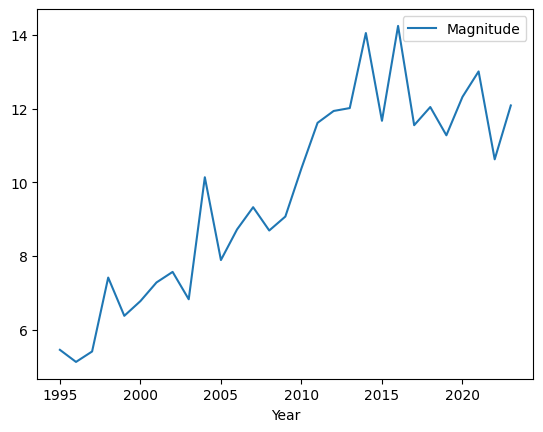

In [106]:
exo.groupby('Year')['Magnitude'].mean().plot(kind='line', legend=True);

- It looks like the brightest planets were discovered first, which makes sense. 

- NASA's Kepler space telescope began its nine-year mission in 2009, leading to a boom in the discovery of exoplanets.

### Understanding Line plots

- Line plots show trends in numerical variables over time.
- To create one from a DataFrame `df`, use
```py
df.plot(
    kind='line', 
    x=x_column_for_horizontal, 
    y=y_column_for_vertical
)
```
- To use the index as the x-axis, omit the `x=` argument.
    - This doesn't work for scatterplots, but it works for most other plot types.

## Bar charts 📊

- How big are each of the different `'Type'`s of exoplanets, on average?

In [107]:
types = exo.groupby('Type')[['Magnitude', 'Mass', 'Radius']].mean()
types

,Magnitude,Mass,Radius
Type,,,
Gas Giant,10.304466,1472.386060,12.739105
Neptune-like,13.519442,15.275549,3.108794
Super Earth,13.846402,5.806297,1.579297
Terrestrial,13.447959,1.618910,0.853870


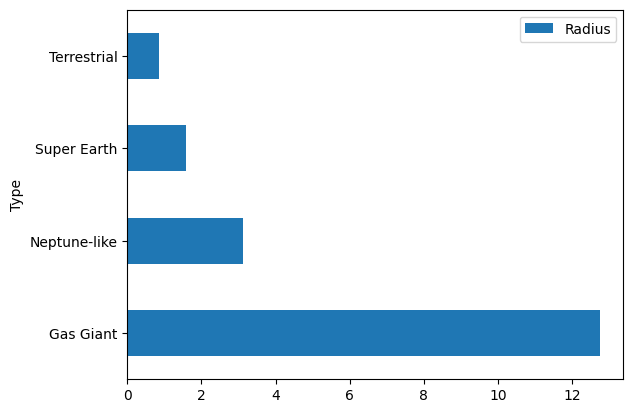

In [108]:
types.plot(kind='barh', y='Radius');

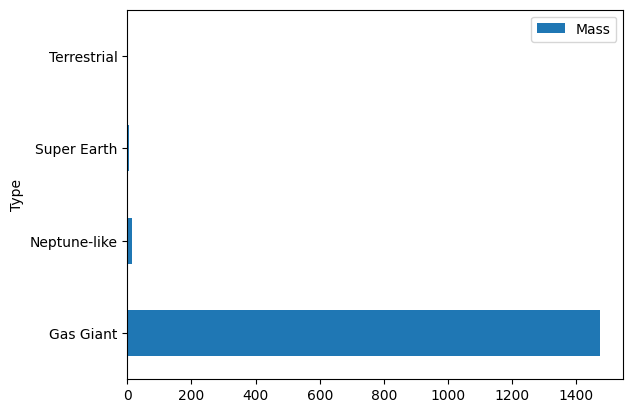

In [109]:
types.plot(kind='barh', y='Mass');

### Understanding Bar Charts

- Bar charts visualize the relationship between a categorical variable and a numerical variable.
- In a bar chart...
    - The thickness and spacing of bars is arbitrary.
    - The order of the categorical labels doesn't matter.
- To create one from a DataFrame `df`, use
```py
df.plot(
    kind='barh', 
    x=categorical_column_name, 
    y=numerical_column_name
)
```
- The **"h"** in `'barh'` stands for **"horizontal"**.
    - It's easier to read labels this way.
- Note that in the previous chart, we set `y='Mass'` even though mass is measured by x-axis length.

### Bar charts and sorting

What are the most popular `'Detection'` methods for discovering exoplanets?

In [110]:
# Count how many exoplanets are discovered by each detection method.
popular_detection = exo.groupby('Detection').count()
popular_detection

,Distance,Magnitude,Type,Year,Mass,Radius
Detection,,,,,,
Astrometry,1,1,1,1,1,1
Direct Imaging,50,50,50,50,50,50
Disk Kinematics,1,1,1,1,1,1
Eclipse Timing Variations,14,14,14,14,14,14
Gravitational Microlensing,12,12,12,12,12,12
Orbital Brightness Modulation,6,6,6,6,6,6
Pulsar Timing,1,1,1,1,1,1
Pulsation Timing Variations,2,2,2,2,2,2
Radial Velocity,1019,1019,1019,1019,1019,1019


In [111]:
# Give columns more meaningful names and eliminate redundancy.
popular_detection = (popular_detection.assign(Count=popular_detection.get('Distance'))
                                      .get(['Count'])
                                      .sort_values(by='Count', ascending=False)
                    )
popular_detection

,Count
Detection,
Transit,3914
Radial Velocity,1019
Direct Imaging,50
Transit Timing Variations,23
Eclipse Timing Variations,14
Gravitational Microlensing,12
Orbital Brightness Modulation,6
Pulsation Timing Variations,2
Astrometry,1


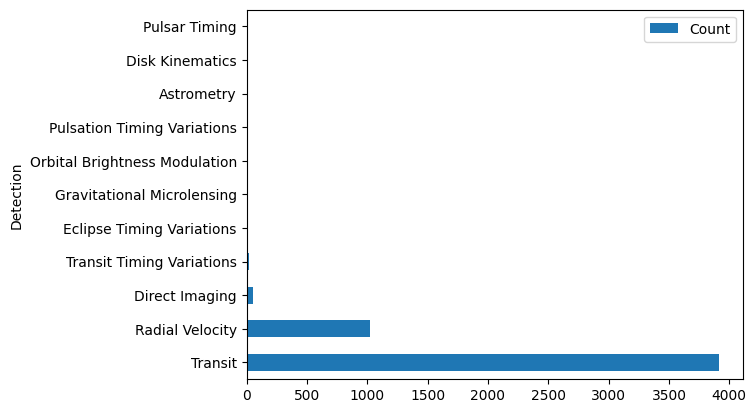

In [112]:
# Notice that the bars appear in the opposite order relative to the DataFrame.
popular_detection.plot(kind='barh', y='Count');

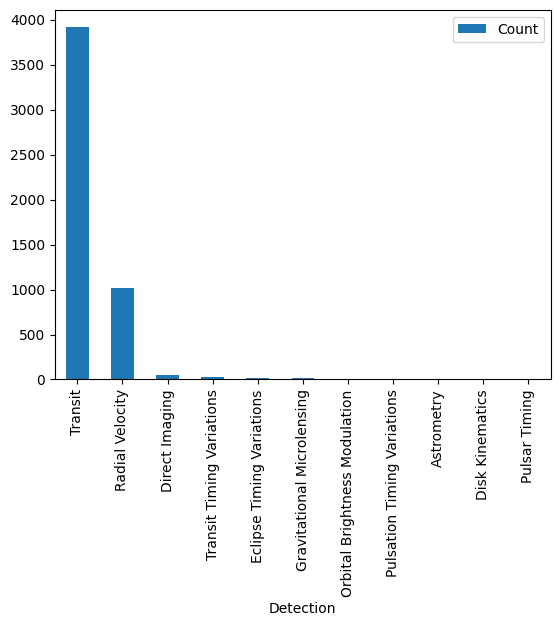

In [113]:
# Change "barh" to "bar" to get a vertical bar chart. 
# These are harder to read, but the bars do appear in the same order as the DataFrame.
popular_detection.plot(kind='bar', y='Count');

### Multiple plots on the same axes

Can we look at both the average `'Magnitude'` and the average `'Radius'` for each `'Type'` at the same time?

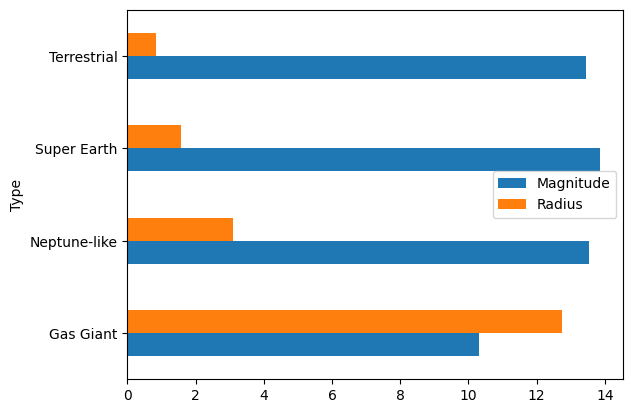

In [114]:
types.get(['Magnitude', 'Radius']).plot(kind='barh');

### Overlaying plots

When calling `.plot`, if we omit the `y=column_name` argument, **all other columns** are plotted.

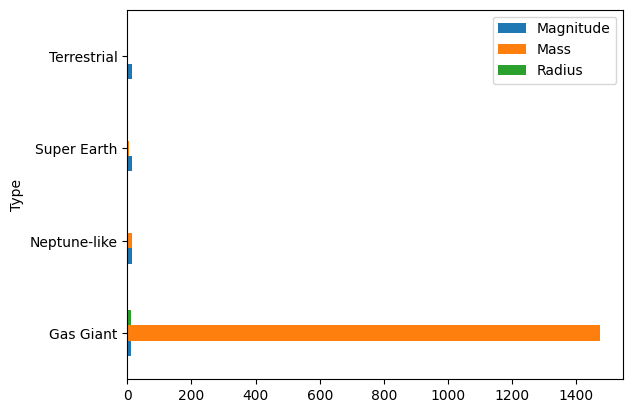

In [116]:
types.plot(kind='barh');

### Plotting multiple columns at once

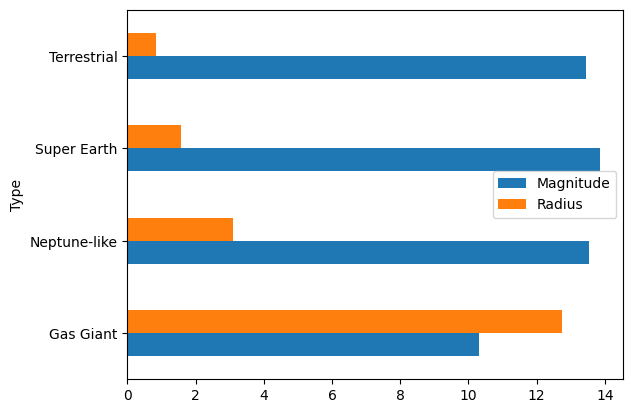

In [117]:
types[['Magnitude', 'Radius']].plot(kind='barh');

## Summary

- Visualizations help reveal patterns and relationships in data.  
- Variables can be categorical or numerical, and this distinction determines which plots are most appropriate.  
- Common visualization types include scatter plots, line plots, and bar charts.

---
### Acknowledgment
Adapted from course materials for DSC 10: Principles of Data Science (UC San Diego), originally authored by Janine Tiefenbruck. Modified for demonstration within the ContentGen project.
